Given $Eu$ has no net electronic spin we have a slightly different spin Hamiltonian
$$H = \underbrace{\mu_{n}\times B\times g_{n}\times I}_{\textrm{Nuclear Zeeman}}+\underbrace{I\times Q\times I}_{Quadrupole}$$

As per [Longdell et. al.](10.1103/PhysRevB.74.195101). This work focuses on $Pr$, with $\frac{5}{2}$ nuclear spin, that sits in a $C_{1}$ symmetry site. Note the work uses $B\times M\times I$ for its nuclear zeeman terms so we will divide M by the nuclear magneton.

In [1]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from copy import deepcopy
import sys
from matplotlib.patches import Rectangle
from scipy.sparse.linalg import inv as spinv
from scipy.sparse import block_diag

from IPython.display import display, Latex
from pathos.multiprocessing import ProcessingPool as Pool


In [2]:
plt.rc('xtick', labelsize=16) 
plt.rc('ytick', labelsize=16) 
plt.rc('axes',labelsize=20)
plt.rc('axes',titlesize=20)

In [3]:
ground=spin.hamilFromYAML("./ion_params/Pr_YSO.yml")
#ground=spin.hamilFromYAML("./ion_params/Er_YSO_site1_ground.yml")


#Hcalc=lambda B,self: self.H+self.electronicZeeman(B)
Hcalc=lambda B,self: self.H+self.nuclearZeeman(B)
#A = ground.genAMatrix(spin.muB*ground.gE,ground.S)
A = ground.genAMatrix(ground.M,ground.I,electronic=False)

ground.Hfunc=Hcalc
ground.A=A

{'Spin': {'Espin': '0', 'Ispin': '5/2'}, 'Quadrupole': {'Q': 'np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*h', 'Q_rot': 'np.array([-94,58.1,-20.7])*np.pi/180'}, 'N_Zeeman': {'M': 'np.matrix(np.diag([2.86,3.05,11.56]))*10*1E6*h', 'M_rot': 'np.array([-99.7,55.7,-40])*np.pi/180'}}


In [4]:
%matplotlib inline
#Zero Field
from scipy.spatial.transform import Rotation


Rx = lambda a : np.matrix([[1,0,0],[0,np.cos(a),-np.sin(a)],[0,np.sin(a),np.cos(a)]])
Ry = lambda a : np.matrix([[np.cos(a),0,np.sin(a)],[0,1,0],[-np.sin(a),0,np.cos(a)]])
Rz = lambda a : np.matrix([[np.cos(a),-np.sin(a),0],[np.sin(a),np.cos(a),0],[0,0,1]])



Bf = 0.3
Bu=np.matrix([1,1,1]).T


#Back and foward propgation
xs=np.linspace(0,Bf,500)
#xs = np.concatenate((np.zeros(20),xs,Bf*np.ones(20)))


#Calculate our hamiltonian at this B Field
F=np.zeros((len(xs),ground.dim))
Fpx=np.zeros((len(xs),ground.dim,3))
Fppx=np.zeros((len(xs),ground.dim,3,3),dtype = np.csingle)

#Ax=ground.nuclearZeeman(np.matrix([1,0,0]).T)
#Ay=ground.nuclearZeeman(np.matrix([0,1,0]).T)
#Az=ground.nuclearZeeman(np.matrix([0,0,1]).T)



C:\Users\neb16\AppData\Local\Temp/ipykernel_22452/1045477650.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  Fpx[i,:,j]= ground.firstOrderEnergySensitivity(VG,A[j])#+ground.firstOrderEnergySensitivity(VG,Ay)#x =


Es: [-54.98528163 -38.66260764 -25.74151503  -8.26238747  12.59541798
  37.26887426]


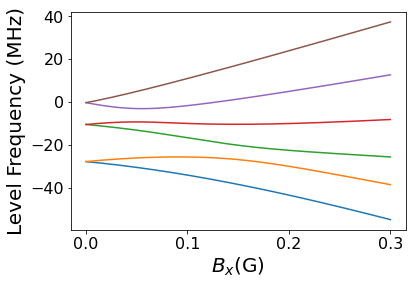

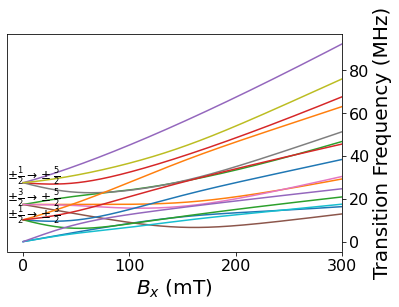

In [5]:
for i,x in enumerate(xs):
    B = Bu*x            
    HG = ground.calcH(B)
    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F[i,:]=FG*1E3
    for j in range(3):
        Fpx[i,:,j]= ground.firstOrderEnergySensitivity(VG,A[j])#+ground.firstOrderEnergySensitivity(VG,Ay)#x = 
    Fppx[i,:] = ground.curvatureCalculation(A[0],A[1],A[2],VG,FG,indiv=False).T

plt.plot(xs,F)
plt.xlabel("$B_{x}$(G)")
plt.ylabel("Level Frequency (MHz)")
plt.savefig("../images/Pr_level.pgf",bbox_inches='tight')
print("Es:", F[-1,:])

plt.show()
plt.close()


Ts = spin.eachElemFunc(F,F,ax=1)
Tds=spin.eachElemFunc(Fpx,Fpx,ax=1)
Tdds=spin.eachElemFunc(Fppx,Fppx,ax=1)

#fig = plt.figure(figsize=(10,10))

#Clip to only single transition direction
half=np.squeeze(np.argwhere(np.sign(Ts[0,:])==1))#int((ground.dim**2)/2)-1
Ts=Ts[:,half]
Tds=Tds[:,half]
Tdds=Tdds[:,half,:,:]


plt.plot(xs*1E3,Ts)
plt.xlim([None,Bf*1E3])
plt.xlabel("$B_{x}$ (mT)")
plt.ylabel("Transition Frequency (MHz)")

plt.annotate(r"$\pm\frac{1}{2}\rightarrow\pm\frac{5}{2}$",(-10,28),(-15,29),fontsize='large')
plt.annotate(r"$\pm\frac{3}{2}\rightarrow\pm\frac{5}{2}$",(-10,18),(-15,19),fontsize='large')
plt.annotate(r"$\pm\frac{1}{2}\rightarrow\pm\frac{3}{2}$",(-10,12),(-15,11),fontsize='large')
plt.annotate("Spin Flip",(-50,1),(-15,5),fontsize='large')

#plt.plot([732,732],[0,50],'--')
ax=plt.gca()
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
plt.savefig("../images/Pr_trans.pgf",bbox_inches='tight')

plt.show()
plt.close()

print()

In [6]:
#fig = plt.figure(figsize=(10,10))
slc=slice(4,-1)
#slc=slice(0,-1)
numr=np.gradient(Ts[slc],axis=0)/(Bf*10)
calc = Tds[slc]

#U@V
vecTimes=lambda U,V: np.squeeze(np.einsum('mr,ndr->ndm',U,V))
#U.T@V@U
tenTimes=lambda U,V: np.squeeze(np.einsum("mr,ndrr,rm->ndm",U.T,V,U))
proj= vecTimes(Bu.T,calc)#calc@unit
xt = xs[slc]

calcdd=(Tdds[slc,:,:,:])
projdd=tenTimes(Bu,calcdd)

error=0.01
dB=Bu*error
T2inv=vecTimes(dB.T,calc)+tenTimes(dB,calcdd)#calcdd*error*calcdd)/60/60
T2=1/(T2inv*np.pi)/60/60
#raise ValueError("Stop you've Violated the law!!!")

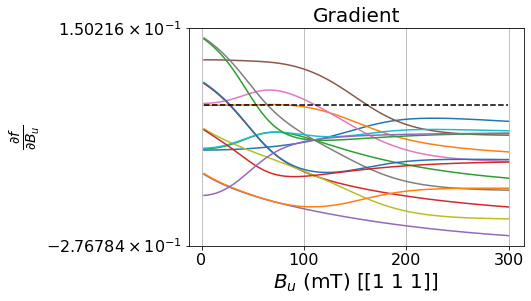

c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


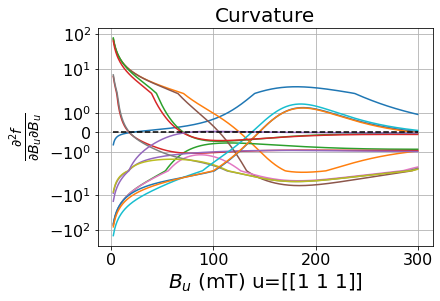

c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


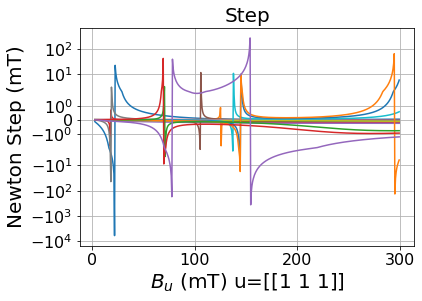

c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


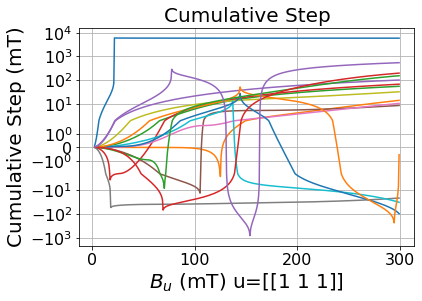

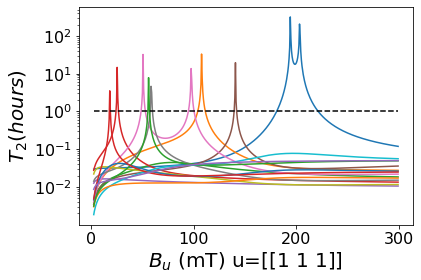

In [7]:

#plt.gca().set_prop_cycle(None)
plt.title("Gradient")
plt.plot(xt*1E3,proj)
#plt.plot(xt*1E3,(numr),'*')
plt.plot(xt*1E3,np.zeros_like(xt),'k--')
plt.xlabel(r"$B_{u}$ (mT) %s"%Bu.T)
plt.ylabel(r"$\frac{\partial f}{\partial B_{u}}$")
plt.yscale("symlog")
plt.grid()
plt.show()
plt.close()


plt.plot(xt*1E3,projdd)
plt.plot(xt*1E3,np.zeros_like(xt),'k--')
#plt.plot(xt*1E3,(numrd),'*')
plt.xlabel(r"$B_{u}$ (mT) u=%s"%Bu.T)
plt.ylabel(r"$\frac{\partial^2 f}{\partial B_{u}\partial B_{u}}$")

plt.title("Curvature")
plt.yscale('symlog')

plt.grid()
plt.show()
plt.close()
#fig = plt.figure(figsize=(10,10))

#starts=np.tile(xt,(calc.shape[1],1)).T
C=1/projdd
plt.plot(xt*1E3,-proj*C)
plt.grid()
plt.title("Step")
plt.yscale('symlog')
plt.xlabel(r"$B_{u}$ (mT) u=%s"%Bu.T)
plt.ylabel("Newton Step (mT)")
plt.show()
plt.close()

plt.plot(xt*1E3,np.cumsum(-(C)*np.abs(proj),axis=0))
plt.grid()
plt.title("Cumulative Step")
plt.yscale('symlog')
plt.xlabel(r"$B_{u}$ (mT) u=%s"%Bu.T)
plt.ylabel("Cumulative Step (mT)")
plt.show()
plt.close()



plt.plot(xt*1E3,np.abs(T2/np.pi))
plt.plot(xt*1E3,np.ones_like(xt),'k--')
plt.yscale('log')
plt.xlabel(r"$B_{u}$ (mT) u=%s"%Bu.T)
plt.ylabel(r"$T_{2}(hours)$")
plt.show()
plt.close()


#raise ValueError("Stop you've Violated the law!!!")

In [8]:
%%script false
B = np.matrix([664,372,971]).T*1E-4
HG = Hstep(B)#ground.H+ground.nuclearZeeman(B)#/spin.muN
FG,VG = ground.getEigFreq(HG)
F=FG*1E3


Ts = spin.eachElemFunc(F,F,ax=0)

#Elevels=[r"$-\frac{1}{2}$",r"$+\frac{1}{2}$",r"$-\frac{3}{2}$",r"$+\frac{3}{2}$",r"$-\frac{5}{2}$",r"$+\frac{5}{2}$"]
#Elevels=[r"$+\frac{1}{2}$",r"$-\frac{1}{2}$",r"$+\frac{3}{2}$",r"$-\frac{3}{2}$",r"$+\frac{5}{2}$",r"$-\frac{5}{2}$"]
#Elevels=[r"$+\frac{5}{2}$",r"$+\frac{3}{2}$",r"$+\frac{1}{2}$",r"$-\frac{1}{2}$",r"$-\frac{3}{2}$",r"$-\frac{5}{2}$"]
Elevels=[r"$-\frac{5}{2}$",r"$+\frac{5}{2}$",r"$-\frac{3}{2}$",r"$+\frac{3}{2}$",r"$-\frac{1}{2}$",r"$+\frac{1}{2}$"]
a=np.repeat(Elevels,len(Elevels))
b=np.tile(Elevels,len(Elevels))



for i,t in enumerate(Ts):
    display(Latex(r"%s : %s $\rightarrow$ %s : %s"%(i,a[i],b[i],t)))


#raise SystemExit("Stop! You've Violated the Law!")


#print(B)
#B=RM@B
#convert spherical Magnetic field to cartesian coords.
#B =RB@B
#B=spin.sphereCart(x,*rt)
#print(B)
        



Couldn't find program: 'false'


In [9]:
#@dask.delayed
def singleLoop(B):
    #print(params,flush=True)
    #global ground
    #convert spherical Magnetic field to cartesian coords.
    #B = np.matrix([X,Y,Z]).T
    #Calculate our hamiltonian at this B Field
    HG = ground.calcH(B)#Hcalc(B)#ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG*1E3
    
    Fp = []
    #OS = np.zeros((ground.dim,3),dtype = np.csingle)
    for l in range(3):
        v = ground.firstOrderEnergySensitivity(VG,A[l])
        Fp.append(v)
    Fp = np.array(Fp).T
    #Fpp = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG,indiv=False).T#*spin.muN
    Fpp = ground.curvatureCalculationNaive(A[0],A[1],A[2],VG,FG,indiv=False).T#*spin.muN
    
    return (F,Fp,Fpp)
#@dask.delayed

def freqs(B):
    
    HG = Hcalc(B.T)#ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG*1E3
    return F
def sweep(Bs):
    F=np.zeros((len(Bs),ground.dim))
    Fp=np.zeros((len(Bs),ground.dim,3),dtype = np.csingle)
    Fpp=np.zeros((len(Bs),ground.dim,3,3),dtype = np.csingle)

    for i in range(Bs.shape[0]):
        F[i,:],Fp[i,:],Fpp[i,:] = singleLoop(Bs[i,:].T)
    return spin.eachElemFunc(F,F,ax=1),spin.eachElemFunc(Fp,Fp,ax=1),spin.eachElemFunc(Fpp,Fpp,ax=1)

def multiSweep(Bs):
    #if __name__ == '__main__':
    F=np.zeros((len(Bs),ground.dim))
    Fp=np.zeros((len(Bs),ground.dim,3),dtype = np.csingle)
    Fpp=np.zeros((len(Bs),ground.dim,3,3),dtype = np.csingle)
    with Pool() as pool:
        #F,Fp,Fpp=pool.map(ground.calcBOptParams,Bs)
        for i,result in enumerate(pool.map(ground.calcBOptParams,Bs)):#range(Bs.shape[0]):
            F[i,:],Fp[i,:],Fpp[i,:]=result

    return spin.eachElemFunc(F,F,ax=1),spin.eachElemFunc(Fp,Fp,ax=1),spin.eachElemFunc(Fpp,Fpp,ax=1)
    
def printRegionsXY(CR):
    for R in CR:
        #print(R)
        h=R[1][1]-R[1][0]
        w = R[0][1]-R[0][0]
        #print(R[0:1][0],w,h)
        ax=plt.gca()
        ax.add_patch(Rectangle([R[0][0],R[1][0]],w,h,fill=False))


def NewtonMethodStep(B,Fp,Fpp,gamma=2,th=1E4):
    B = B.reshape(1,-1).T
    V = Fp.reshape(1,-1).T
    S = (np.linalg.inv(Fpp))
    
    #S[np.argwhere(np.abs(S)>th)]=1
    #S=np.clip(S,-th,th)
    #S[S>=th**2]=1
    #if np.any(np.isinf(S)) or np.any(np.isneginf(S)):
    #    S=np.eye(S.size)

    C=(block_diag(S))    
    #print(C)
    step=2*C@V
    #step=np.clip(step,-gamma,gamma)
    newB = B-step
    #print(newB)
    newB = newB.T.reshape(-1,3)
    #print(newB)
    bad = np.argwhere(np.any(np.abs(newB)>th,axis=1))
    #print("Newton", newB)
    #print(np.squeeze(bad))
    newB = np.delete(newB,np.squeeze(bad),axis=0)

        
    return newB

def GradientDescentStep(B,Fp,i,gamma=2,th=1E4):
    B = B.reshape(1,-1).T
    V = np.real(Fp[:,i,:].reshape(1,-1).T)
    newB = B-gamma*V
    #print(newB)
    newB = newB.T.reshape(-1,3)
    #print(newB)
    bad = np.argwhere(np.any(np.abs(newB)>th,axis=1))
    #print("Newton", newB)
    #print(np.squeeze(bad))
    newB = np.delete(newB,np.squeeze(bad),axis=0)

        
    return newB

In [10]:
np.set_printoptions(threshold=np.inf)

pts = 8
half=int((pts**3)/2)+1

ps=-0.5
pe = 0.5

Bxi = np.linspace(ps,pe,pts)
Byi = Bxi
Bzi = Bxi

Bx,By,Bz = np.meshgrid(Bxi,Byi,Bzi)
Bsi = np.array(np.meshgrid(Bxi,Byi,Bzi)).reshape(3,-1).T
#delta = (Bxi[-1]-Bxi[0])/len(Bxi)
Bs=Bsi



c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to rea

ValueError: need at least one array to concatenate

c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


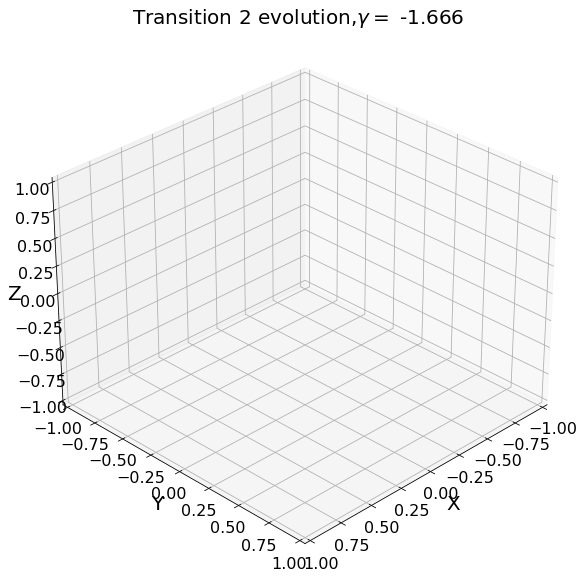

In [11]:

from matplotlib import animation
from functools import partial
#from mpl_toolkits.mplot3d import Axes3D

fig=plt.figure(figsize=(10,10))
#ax = plt.axes()
#fig, ax = plt.subplots()
ax=fig.add_subplot(projection='3d')
#bg = ax.pcolor(Bx[:,:,0],By[:,:,0],np.real(Fi[:,t].reshape(pts,pts)).T,cmap='nipy_spectral',shading='auto')
#pe*=1E4
zpts,=ax.plot([],[],[],'*')
#pe=1E4/2
ax.set(xlim3d=(-2*pe, 2*pe), xlabel='X')
ax.set(ylim3d=(-2*pe, 2*pe), ylabel='Y')
ax.set(zlim3d=(-2*pe, 2*pe), zlabel='Z')
ax.view_init(azim=45, elev=30)
##pts=ax.plot()

#plt.legend()
#plt.plot(,'b.')
#bg.colorbar()
S = 2E-0
F = 1E-3
frames = 250
tau = -frames/np.log(F/S)
tauo = frames/np.log(S-F+1)
m=(F-S)/-frames
#frames = 200
t=2
ax.set(title="Transition %s evolution"%t)


SA = lambda f: S*np.exp(-f/tau)
SAo = lambda f: (S-np.exp(f/tauo)+1)
SAl =lambda f: S-m*f
#plt.plot(Bxi,Fi[:,t],'*-')
#
global Bf
#Bsi = 
Bf=np.array(np.meshgrid(Bxi,Byi,Bzi)).reshape(3,-1).T
Bf=Bf[:half,:]
#Bf=BZP

def init():
    #pass
    #ax.set_xlim(-5,5)
    #ax.set_ylim(-5,5)
    #zpts,=ax.plot([],[],'*')
    zpts.set_data(Bf[:,0],Bf[:,1])
    zpts.set_3d_properties(Bf[:,2])

    #pts.set_data(Bf[:,0],Bf[:,1]) 
    return zpts,

def update(frame):
    global Bf
    g=-SA(frame)
    ax.set(title="Transition %s evolution,$\gamma=$ %s"%(t,np.around(g,3)))

    zpts.set_data(Bf[:,0],Bf[:,1])
    zpts.set_3d_properties(Bf[:,2])
    F,Fp,Fpp=multiSweep(Bf)
    #print(Fp)
    #F,Fp,Fpp=sweepSingleTrans(Bf,0,2)
    
    #F,Fp,Fpp=sweep(Bf)
    Bf = NewtonMethodStep(Bf,Fp[:,t,:],Fpp[:,t,:,:],gamma=1,th=1E9)
    #Bf = NewtonMethodStep(Bf,Fp,Fpp,gamma=0.1,th=1E4)
    
    #Bf=GradientDescentStep(Bf,Fp,t,gamma=g)
    #print(frame)
    return zpts,

ani=animation.FuncAnimation(fig,update,init_func=init,blit=True,frames=frames,interval=1)
ani.save('test.mp4', fps=30)

#plt.show()
#plt.close()



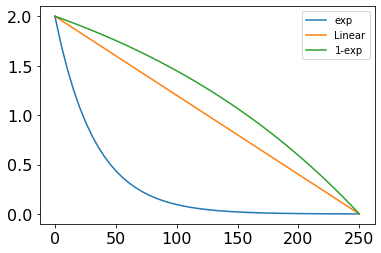

In [ ]:
#plt.close()
fs = np.linspace(0,frames)
plt.plot(fs,SA(fs),label="exp")
plt.plot(fs,SAl(fs),label="Linear")
plt.plot(fs,SAo(fs),label="1-exp")
plt.legend()
plt.show()
plt.close()

ZEFOZ points:  [[-2505000.     +0.j -2505000.     +0.j -2505000.     +0.j]
 [-2505000.     +0.j -2505000.     +0.j -2503570.     +0.j]
 [-2505000.     +0.j -2505000.     +0.j -2502140.     +0.j]
 [-2505000.     +0.j -2505000.     +0.j -2498420. -28150.j]
 [-2505000.     +0.j -2505000.     +0.j  2500710.     +0.j]
 [-2505000.     +0.j -2505000.     +0.j  2502140.     +0.j]
 [-2505000.     +0.j -2505000.     +0.j  2503570.     +0.j]
 [-2505000.     +0.j -2505000.     +0.j  2505000.     +0.j]
 [-2505000.     +0.j -2503570.     +0.j -2505000.     +0.j]
 [-2505000.     +0.j -2503570.     +0.j -2503570.     +0.j]
 [-2505000.     +0.j -2503570.     +0.j -2500710.     +0.j]
 [-2505000.     +0.j -2503570.     +0.j  2493780. -18680.j]
 [-2505000.     +0.j -2503570.     +0.j  2502140.     +0.j]
 [-2505000.     +0.j -2503570.     +0.j  2503570.     +0.j]
 [-2505000.     +0.j -2503570.     +0.j  2505000.     +0.j]
 [-2505000.     +0.j -2502140.     +0.j -2505000.     +0.j]
 [-2505000.     +0.j -250

c:\Users\neb16\Documents\Uni\PHD\Experiments\Simulations\Spin_Hamiltonian\spin_hamiltonian\spin_hamiltonian.py:435: RuntimeWarning: invalid value encountered in true_divide
  pdb=lambda A,B,n,m: np.trace(np.nan_to_num(((V[:,m].H)@A@V[:,n])@((V[:,n].H)@B@V[:,m])/(E[n]-E[m]),posinf=0,nan=0,neginf=0))


(250.5+0j)
Ft (10000, 36)
Fr (100, 100)
(8, 8, 8) (8, 8, 8)


c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


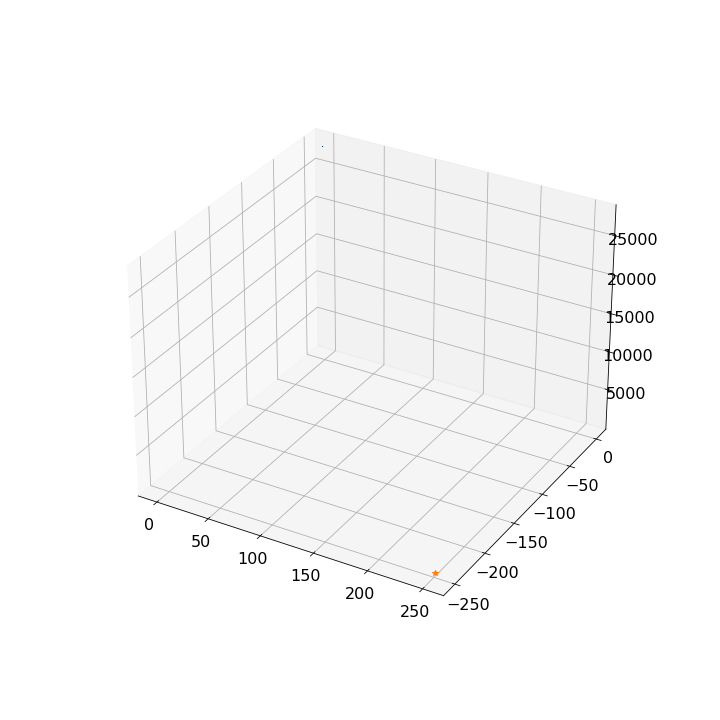

In [ ]:
#%%script false
%matplotlib widget
#print(Bzi)

ZFP = np.unique(np.around(Bf,3),axis=0)

print("ZEFOZ points: ",ZFP*1E4)

idx=-1

z=ZFP[idx][2]#np.argwhere(Bzi==-4)
y=ZFP[idx][1]#np.argwhere(Bzi==-4)

print(z)

pts = 100
Bxi = np.linspace(-0.2,0.2,pts)
X,Y = np.meshgrid(Bxi,Bxi)
Bsi = np.array(np.meshgrid(Bxi,Bxi,z)).reshape(3,-1).T
print(Bsi.shape)
Ft,_,_=sweep(Bsi)


print(z)
print("Ft",Ft.shape)
fr = np.squeeze(np.real(Ft[:,t].T.reshape(pts,pts,-1)))
print("Fr",fr.shape)
print(Bx.shape,By.shape)
#plt.pcolor(Bxi,Byi,fr[:,:,1],cmap='nipy_spectral',shading='auto')
#plt.plot()
#print(BZP)


fig=plt.figure(figsize=(10,10))
#ax = plt.axes()
#fig, ax = plt.subplots()
ax=fig.add_subplot(projection='3d')
ax.plot_surface(X,Y,np.real(fr),alpha=0.5)
ax.plot(*ZFP[idx],'*')
plt.show()
#plt.close()


In [1]:
%matplotlib inline
idx = idx
#idx= -2
P=ZFP[idx]



Bxi = np.linspace(-0.2,0.2,pts)
X,Y = np.meshgrid(Bxi,Bxi)
Fxy,_,_=sweep(np.array(np.meshgrid(Bxi,Bxi,P[2])).reshape(3,-1).T)
Fxy= np.squeeze(np.real(Fxy[:,t].T.reshape(pts,pts,-1)))
Fyz,_,_=sweep(np.array(np.meshgrid(P[0],Bxi,Bxi)).reshape(3,-1).T)
Fyz= np.squeeze(np.real(Fyz[:,t].T.reshape(pts,pts,-1)))
Fxz,_,_=sweep(np.array(np.meshgrid(Bxi,P[1],Bxi)).reshape(3,-1).T)
Fxz= np.squeeze(np.real(Fxz[:,t].T.reshape(pts,pts,-1)))



print("Fr",fr.shape)



fig = plt.figure(figsize=(30,5))
plt.set_cmap('nipy_spectral')

marker_style = dict(color='b', marker='o',
                    markersize=5)
fig.suptitle("ZEFOZ Environment T: %s, B:(%s,%s,%s)mT"%(t,P[0]*1E3,P[1]*1E3,P[2]*1E3),fontsize=30)
ax = plt.subplot(1,3,1)
plt.pcolor(X,Y,Fxy,cmap='nipy_spectral',shading='auto')
plt.plot(P[0],P[1],**marker_style)
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar()

ax = plt.subplot(1,3,2)
plt.pcolor(X,Y,Fyz.T,cmap='nipy_spectral',shading='auto')
plt.plot(P[1],P[2],**marker_style)
plt.xlabel("Y")
plt.ylabel("Z")
plt.colorbar()

ax = plt.subplot(1,3,3)
plt.pcolor(X,Y,Fxz.T,cmap='nipy_spectral',shading='auto')
plt.plot(P[0],P[2],**marker_style)
plt.xlabel("X")
plt.ylabel("Z")

plt.colorbar()

#for i in range(int(Fi.shape[3]/4)):
#ax.plot_surface(X,Y,np.real(Fi[:,:,Z,T]))



#plt.legend()
plt.savefig("../images/grad_desc_ZFcan.pdf",bbox_inches='tight')
plt.show()
plt.close()


NameError: name 'idx' is not defined